## Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### Define Decision Boundary Plot Function

In [2]:
def plot_dcsbound(reduced_data, kmeans):
    # Step size of the mesh. Decrease to increase the quality of the VQ.
    h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

    # Plot the decision boundary. For that, we will assign a color to each
    x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
    y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Obtain labels for each point in mesh. Use last trained model.
    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure(1)
    plt.clf()
    plt.imshow(
        Z,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        cmap=plt.cm.Paired,
        aspect="auto",
        origin="lower",
    )

    plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
    # Plot the centroids as a white X
    centroids = kmeans.cluster_centers_
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=169,
        linewidths=3,
        color="w",
        zorder=10,
    )
    # plt.title(
    #     "K-means clustering on the digits dataset (PCA-reduced data)\n"
    #     "Centroids are marked with white cross"
    # )
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xticks(())
    plt.yticks(())
    plt.show()

## Load MNIST dataset

In [3]:
data, labels = load_digits(return_X_y=True)
(n_samples, n_features), n_digits = data.shape, np.unique(labels).size
print(f"# digits: {n_digits}; # samples: {n_samples}; # features {n_features}")

# digits: 10; # samples: 1797; # features 64


## init=k-means++

### Plot K=[1...40]

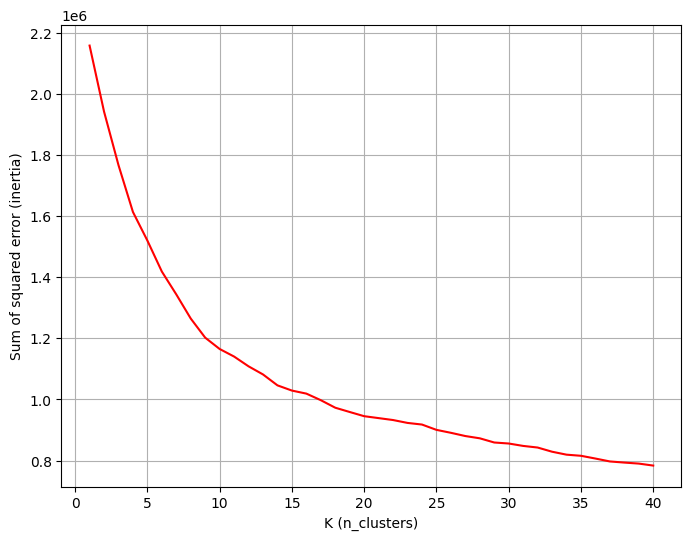

CPU times: user 5.08 s, sys: 2.93 s, total: 8.01 s
Wall time: 4.38 s


In [4]:
%%time

wcss_kmpp = []  # within-cluster sum-of-squares
for i in range(1, 41):
    kmeans = KMeans(init="k-means++", n_clusters=i, n_init=1, random_state=0)
    kmeans.fit(data)
    wcss_kmpp.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.xlabel('K (n_clusters)')
plt.ylabel('Sum of squared error (inertia)')
plt.grid()
plt.plot(range(1,41), wcss_kmpp, color='red')
plt.show()

### Plot the Decision Boundary with Centroids (PCA-reduced Data)

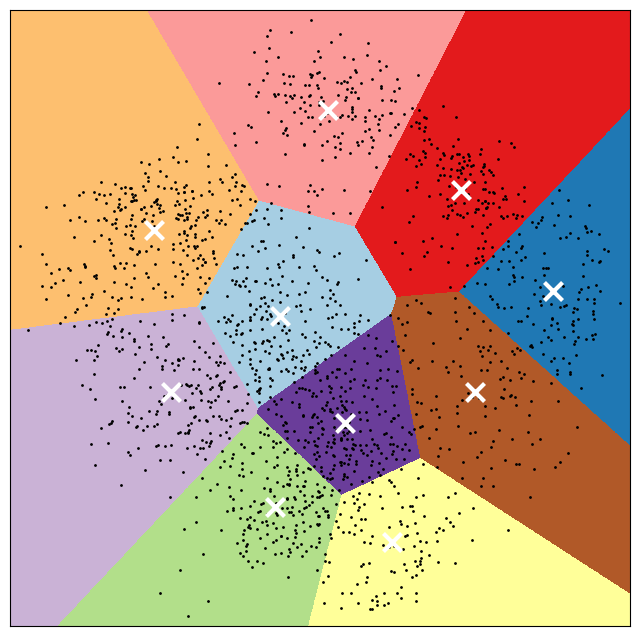

Inertia: 57304.14947234772


In [5]:
reduced_data = PCA(n_components=2).fit_transform(data)
kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=1, random_state=0)
kmeans.fit(reduced_data)

plt.figure(figsize=(8, 8))
plot_dcsbound(reduced_data, kmeans)

print('Inertia:', kmeans.inertia_)

## init=random

### Plot K=[1...40]

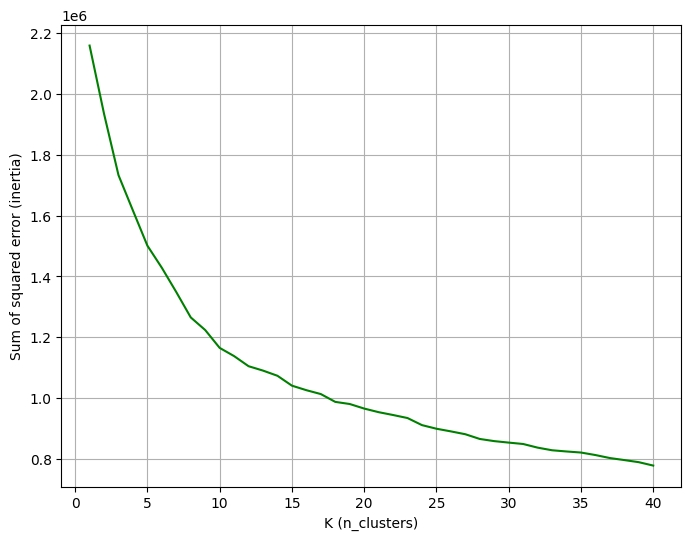

CPU times: user 1.3 s, sys: 123 ms, total: 1.42 s
Wall time: 780 ms


In [6]:
%%time

wcss_rand = []  # within-cluster sum-of-squares
for i in range(1, 41):
    kmeans = KMeans(init="random", n_clusters=i, n_init=1, random_state=0)
    kmeans.fit(data)
    wcss_rand.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.xlabel('K (n_clusters)')
plt.ylabel('Sum of squared error (inertia)')
plt.grid()
plt.plot(range(1,41), wcss_rand, color='green')
plt.show()

### Plot the Decision Boundary with Centroids (PCA-reduced Data)

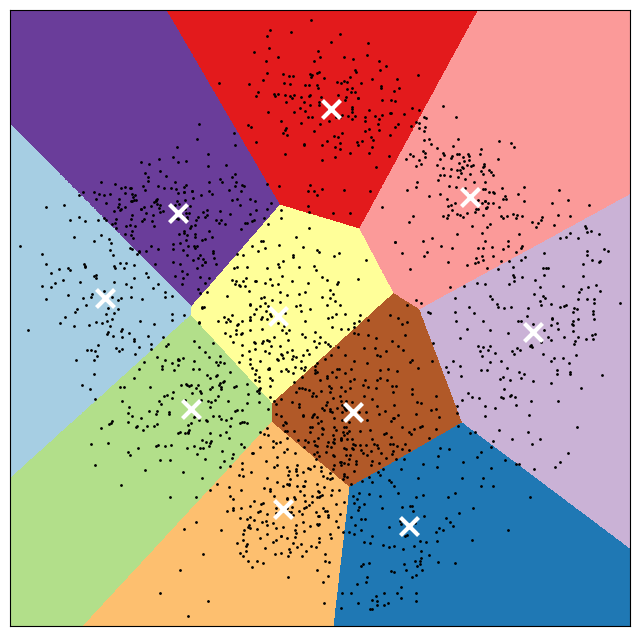

Inertia: 56387.352799452136


In [7]:
reduced_data = PCA(n_components=2).fit_transform(data)
kmeans = KMeans(init="random", n_clusters=n_digits, n_init=1, random_state=0)
kmeans.fit(reduced_data)

plt.figure(figsize=(8, 8))
plot_dcsbound(reduced_data, kmeans)

print('Inertia:', kmeans.inertia_)

## init=PCA-based

### Plot K=[1...40]

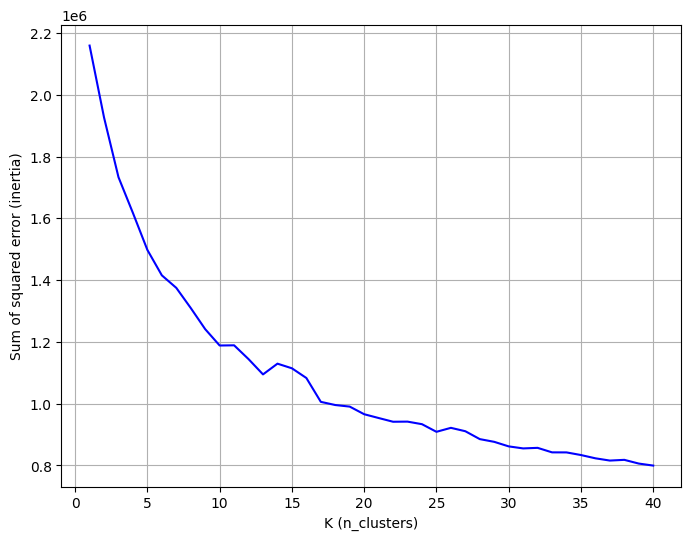

CPU times: user 6.17 s, sys: 2.98 s, total: 9.15 s
Wall time: 6.3 s


In [8]:
%%time

wcss_pcab = []  # within-cluster sum-of-squares
for i in range(1, 41):
    pca = PCA(n_components=i).fit(data)
    kmeans = KMeans(init=pca.components_, n_clusters=i, n_init=1)
    kmeans.fit(data)
    wcss_pcab.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.xlabel('K (n_clusters)')
plt.ylabel('Sum of squared error (inertia)')
plt.grid()
plt.plot(range(1,41), wcss_pcab, color='blue')
plt.show()

## Plot K=[1...40] Comparison

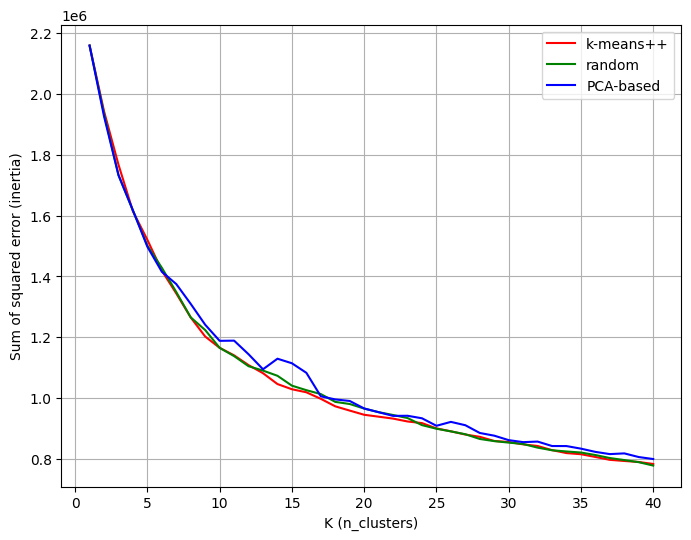

In [9]:
plt.figure(figsize=(8, 6))
plt.xlabel('K (n_clusters)')
plt.ylabel('Sum of squared error (inertia)')
plt.grid()
plt.plot(range(1,41), wcss_kmpp, label='k-means++', color='red')
plt.plot(range(1,41), wcss_rand, label='random', color='green')
plt.plot(range(1,41), wcss_pcab, label='PCA-based', color='blue')
plt.legend()
plt.show()

Reference: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_digits.html